In [1]:
# =============================================================================
# CHUNK 1 — IMPORTS + GLOBAL CONFIG + LOAD DATA
# =============================================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import gc

# Global seed
Randomizer = 485
np.random.seed(Randomizer)

# Load datasets
WineReview_A = pd.read_csv("data/WineReview_A_cleaned.csv")
WineReview_B = pd.read_csv("data/WineReview_B_cleaned.csv")

gc.collect()

0

In [2]:
# =============================================================================
# CHUNK 2 — SENTIMENT NUMERIC + SAFE PREDICTORS + TRAIN/TEST SPLIT
# =============================================================================

sentiment_map = {
    "negative": -1,
    "neutral": 0,
    "positive": 1
}

WineReview_A["sentiment"] = WineReview_A["sentiment"].map(sentiment_map)
WineReview_B["sentiment"] = WineReview_B["sentiment"].map(sentiment_map)

safe_vars = [
    "rating_points",
    "price",
    "word_count",
    "char_count",
    "avg_word_length",
    "sentiment"
]

# Dataset A — cleaned + imputed
train_A, test_A = train_test_split(
    WineReview_A[safe_vars],
    test_size=0.2,
    random_state=Randomizer
)

# Dataset B — raw (remove NA target)
WineReview_B2 = WineReview_B.dropna(subset=["rating_points"])

train_B, test_B = train_test_split(
    WineReview_B2[safe_vars],
    test_size=0.2,
    random_state=Randomizer
)

print(f"Dataset A size: {len(train_A)} train / {len(test_A)} test")
print(f"Dataset B size: {len(train_B)} train / {len(test_B)} test")

Dataset A size: 97258 train / 24315 test
Dataset B size: 103976 train / 25995 test


In [3]:
# =============================================================================
# CHUNK 3 — RANDOM FOREST WITH MANUAL 5-FOLD CV (A & B)
# =============================================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def run_cv_rf(data, target="rating_points", k=5):

    X = data.drop(columns=[target]).values
    y = data[target].values

    kf = KFold(n_splits=k, shuffle=True, random_state=Randomizer)

    rmse_list, mae_list, r2_list = [], [], []

    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = RandomForestRegressor(
            n_estimators=150,
            max_features="sqrt",
            random_state=Randomizer,
            n_jobs=-1
        )

        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        rmse_list.append(np.sqrt(mean_squared_error(y_test, preds)))
        mae_list.append(mean_absolute_error(y_test, preds))
        r2_list.append(r2_score(y_test, preds))

    return {
        "RMSE": np.mean(rmse_list),
        "MAE": np.mean(mae_list),
        "R2": np.mean(r2_list)
    }

cv_A = run_cv_rf(train_A)
cv_B = run_cv_rf(train_B)

print("5-Fold CV Completed for Dataset A")
print("5-Fold CV Completed for Dataset B")
cv_A, cv_B

5-Fold CV Completed for Dataset A
5-Fold CV Completed for Dataset B


({'RMSE': 1.3240226146282796,
  'MAE': 1.0422712496166053,
  'R2': 0.8107038796823073},
 {'RMSE': 1.323503149044879,
  'MAE': 1.042384761221466,
  'R2': 0.8100227043463359})

In [4]:
# =============================================================================
# CHUNK 3 — TOKENIZER (MATCHES R'S unnest_tokens)
# =============================================================================

def tokenize(text):
    if not isinstance(text, str):
        return []
    text = text.lower()
    text = re.sub(r"[^a-zA-Z]", " ", text)   # remove punctuation
    tokens = text.split()                    # split on whitespace
    return [t for t in tokens if t not in stop_words]

In [5]:
# =============================================================================
# CHUNK 4 — FINAL MODELS + EVALUATION + SAVE
# =============================================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

def evaluate(model, test_df, target="rating_points"):
    X_test = test_df.drop(columns=[target]).values
    y_test = test_df[target].values

    preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae  = mean_absolute_error(y_test, preds)
    r2   = r2_score(y_test, preds)

    return {"RMSE": rmse, "MAE": mae, "R2": r2}

# Final RF for Dataset A
final_rf_A = RandomForestRegressor(
    n_estimators=150,
    max_features="sqrt",
    random_state=Randomizer,
    n_jobs=-1
)
final_rf_A.fit(
    train_A.drop(columns=["rating_points"]).values,
    train_A["rating_points"].values
)

# Final RF for Dataset B
final_rf_B = RandomForestRegressor(
    n_estimators=150,
    max_features="sqrt",
    random_state=Randomizer,
    n_jobs=-1
)
final_rf_B.fit(
    train_B.drop(columns=["rating_points"]).values,
    train_B["rating_points"].values
)

print("Final full models trained for A and B")

metrics_A = evaluate(final_rf_A, test_A)
metrics_B = evaluate(final_rf_B, test_B)
metrics_A, metrics_B

joblib.dump(final_rf_A, "models/rf_A_compressed.pkl", compress=3)
joblib.dump(final_rf_B, "models/rf_B_compressed.pkl", compress=3)

Final full models trained for A and B


['models/rf_B_compressed.pkl']

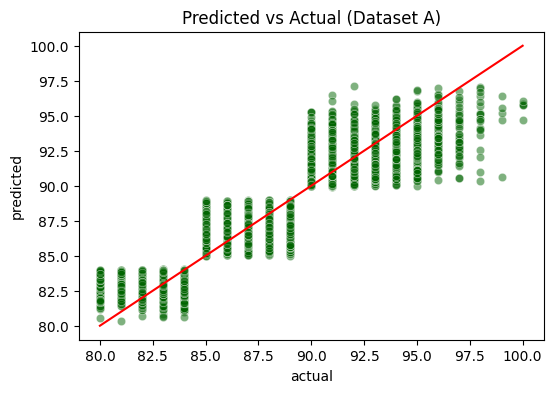

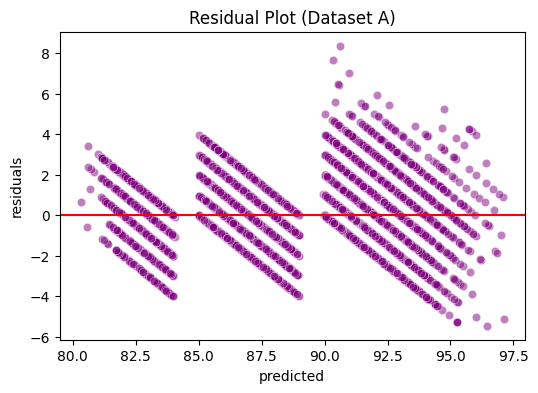

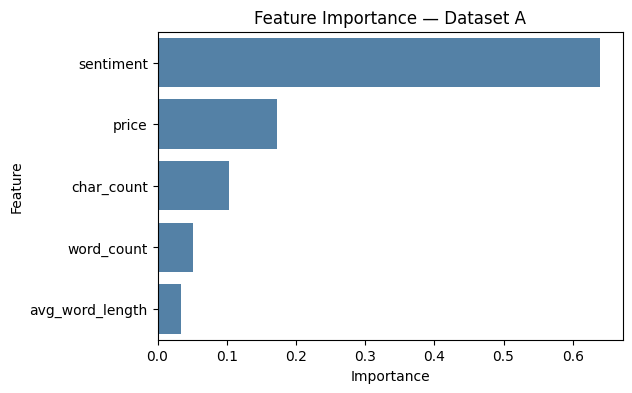

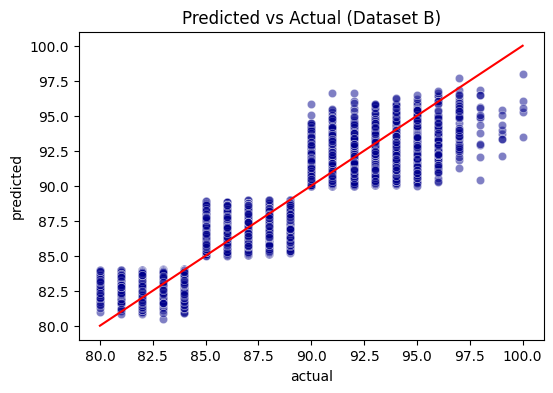

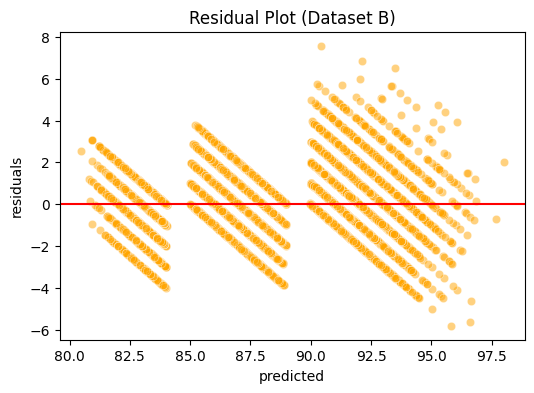

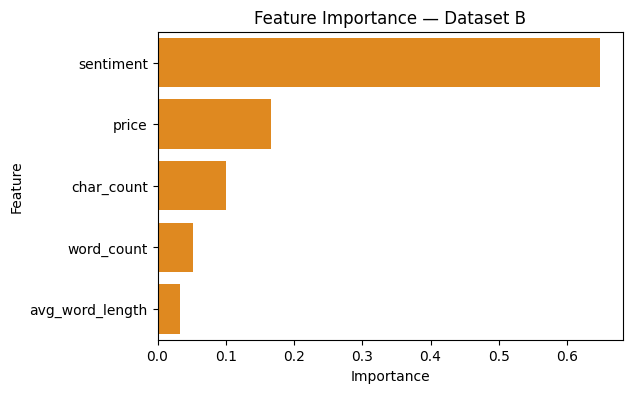

10943

: 

In [ ]:
# =============================================================================
# CHUNK 5 — DIAGNOSTIC PLOTS FOR DATASET A AND DATASET B
# =============================================================================

import seaborn as sns
import matplotlib.pyplot as plt
import gc

# -------------------------
# Dataset A Diagnostics
# -------------------------

df_A = pd.DataFrame({
    "actual": test_A["rating_points"].values,
    "predicted": final_rf_A.predict(
        test_A.drop(columns=["rating_points"]).values
    )
})
df_A["residuals"] = df_A["actual"] - df_A["predicted"]

# Predicted vs Actual
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_A, x="actual", y="predicted", alpha=0.5, color="darkgreen")
plt.plot(
    [df_A.actual.min(), df_A.actual.max()],
    [df_A.actual.min(), df_A.actual.max()],
    color="red"
)
plt.title("Predicted vs Actual (Dataset A)")
plt.show()
plt.close()

# Residual Plot
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_A, x="predicted", y="residuals", alpha=0.5, color="purple")
plt.axhline(0, color="red")
plt.title("Residual Plot (Dataset A)")
plt.show()
plt.close()

# Feature Importance
imp_A = pd.DataFrame({
    "Feature": train_A.drop(columns=["rating_points"]).columns,
    "Importance": final_rf_A.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(data=imp_A, x="Importance", y="Feature", color="steelblue")
plt.title("Feature Importance — Dataset A")
plt.show()
plt.close()

del df_A, imp_A
gc.collect()

# -------------------------
# Dataset B Diagnostics
# -------------------------

df_B = pd.DataFrame({
    "actual": test_B["rating_points"].values,
    "predicted": final_rf_B.predict(
        test_B.drop(columns=["rating_points"]).values
    )
})
df_B["residuals"] = df_B["actual"] - df_B["predicted"]

# Predicted vs Actual
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_B, x="actual", y="predicted", alpha=0.5, color="darkblue")
plt.plot(
    [df_B.actual.min(), df_B.actual.max()],
    [df_B.actual.min(), df_B.actual.max()],
    color="red"
)
plt.title("Predicted vs Actual (Dataset B)")
plt.show()
plt.close()

# Residual Plot
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_B, x="predicted", y="residuals", alpha=0.5, color="orange")
plt.axhline(0, color="red")
plt.title("Residual Plot (Dataset B)")
plt.show()
plt.close()

# Feature Importance
imp_B = pd.DataFrame({
    "Feature": train_B.drop(columns=["rating_points"]).columns,
    "Importance": final_rf_B.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(data=imp_B, x="Importance", y="Feature", color="darkorange")
plt.title("Feature Importance — Dataset B")
plt.show()
plt.close()

del df_B, imp_B
gc.collect()